# 02. Подготовка метаданных

Цель этапа: собрать единую таблицу, где каждая аудиозапись связана с режимом обработки и меткой шероховатости `Ra`.

На выходе создаются файлы:

- `data/processed/roughness_table.csv` - очищенная таблица шероховатости по режимам обработки;
- `data/processed/metadata.csv` - таблица аудиозаписей `.aup` и меток `Ra`;
- `data/processed/condition_summary.csv` - краткая проверка количества запусков по режимам.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Корень проекта:", PROJECT_ROOT)
print("Исходные данные:", DATA_RAW)
print("Обработанные данные:", DATA_PROCESSED)
print("Папка с графиками:", FIGURES_DIR)

Корень проекта: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project
Исходные данные: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\data\raw
Обработанные данные: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\data\processed
Папка с графиками: C:\Users\ivan.kopytin\Desktop\уник\surface_roughness_project\reports\figures


## 1. Проверяем состав исходных данных

В датасете есть Excel-файл с измеренной шероховатостью и Audacity-проекты `.aup`, внутри которых лежат блоки аудио `.au`.


In [2]:
excel_files = sorted(DATA_RAW.rglob("*.xlsx"))
aup_files = sorted(DATA_RAW.rglob("*.aup"))
au_files = sorted(DATA_RAW.rglob("*.au"))

print("Excel-файлов:", len(excel_files))
print("Audacity-проектов .aup:", len(aup_files))
print("Аудио-блоков .au:", len(au_files))

print("\nExcel-файл:")
for path in excel_files:
    print("-", path.relative_to(PROJECT_ROOT))

print("\nПервые 5 .aup:")
for path in aup_files[:5]:
    print("-", path.relative_to(PROJECT_ROOT))

Excel-файлов: 1
Audacity-проектов .aup: 319
Аудио-блоков .au: 7448

Excel-файл:
- data\raw\Milling Surface Roughness Acoustic Sensor Dataset\SurfaceRoughnessValuesConsolidated.xlsx

Первые 5 .aup:
- data\raw\Milling Surface Roughness Acoustic Sensor Dataset\feed-10mm\speed-250rpm\doc-0.25mm\10-250-0.25-1\1.aup
- data\raw\Milling Surface Roughness Acoustic Sensor Dataset\feed-10mm\speed-250rpm\doc-0.25mm\10-250-0.25-10\10.aup
- data\raw\Milling Surface Roughness Acoustic Sensor Dataset\feed-10mm\speed-250rpm\doc-0.25mm\10-250-0.25-11\11.aup
- data\raw\Milling Surface Roughness Acoustic Sensor Dataset\feed-10mm\speed-250rpm\doc-0.25mm\10-250-0.25-12\12.aup
- data\raw\Milling Surface Roughness Acoustic Sensor Dataset\feed-10mm\speed-250rpm\doc-0.25mm\10-250-0.25-13\13.aup


## 2. Чистим таблицу шероховатости

В Excel первая строка является заголовком отчета, поэтому таблицу нужно читать с `header=1`. После этого оставляем только строки с числовыми режимами обработки.


In [3]:
from metadata import clean_roughness_table

excel_path = excel_files[0]
roughness = clean_roughness_table(excel_path)

print("Размер очищенной таблицы шероховатости:", roughness.shape)
display(roughness[["condition_id", "feed_mm", "speed_rpm", "depth_mm", "roughness_ra"]])

Размер очищенной таблицы шероховатости: (16, 22)


,condition_id,feed_mm,speed_rpm,depth_mm,roughness_ra
0,f5_s250_d0.25,5.0,250,0.25,1.57
1,f5_s250_d0.5,5.0,250,0.50,1.97
2,f5_s250_d0.75,5.0,250,0.75,4.06
3,f5_s250_d1,5.0,250,1.00,5.59
4,f5_s500_d0.25,5.0,500,0.25,1.24
5,f5_s500_d0.5,5.0,500,0.50,1.52
6,f5_s500_d0.75,5.0,500,0.75,1.63
7,f5_s500_d1,5.0,500,1.00,1.77
8,f10_s250_d0.25,10.0,250,0.25,3.70
9,f10_s250_d0.5,10.0,250,0.50,3.89


## 3. Собираем единую таблицу метаданных

Режим обработки берется из родительских папок `feed-...`, `speed-...`, `doc-...`. Это важнее, чем имя внутренней папки эксперимента, потому что в датасете встречаются опечатки в названиях внутренних папок.


In [4]:
from metadata import build_dataset_metadata

roughness, metadata = build_dataset_metadata(
    data_raw=DATA_RAW,
    data_processed=DATA_PROCESSED,
    project_root=PROJECT_ROOT,
)

print("Таблица roughness:", roughness.shape)
print("Таблица metadata:", metadata.shape)

main_cols = [
    "condition_id",
    "feed_mm",
    "speed_rpm",
    "depth_mm",
    "run_id",
    "roughness_ra",
    "sample_rate_hz",
    "channels",
    "duration_sec",
    "aup_path",
]
display(metadata[main_cols].head(10))

Таблица roughness: (16, 22)
Таблица metadata: (319, 30)


,condition_id,feed_mm,speed_rpm,depth_mm,run_id,roughness_ra,sample_rate_hz,channels,duration_sec,aup_path
0,f5_s250_d0.25,5.0,250,0.25,1,1.57,44100.0,2,61.445805,data/raw/Milling Surface Roughness Acoustic Se...
1,f5_s250_d0.25,5.0,250,0.25,2,1.57,44100.0,2,63.361451,data/raw/Milling Surface Roughness Acoustic Se...
2,f5_s250_d0.25,5.0,250,0.25,3,1.57,44100.0,2,60.923356,data/raw/Milling Surface Roughness Acoustic Se...
3,f5_s250_d0.25,5.0,250,0.25,4,1.57,44100.0,2,61.112018,data/raw/Milling Surface Roughness Acoustic Se...
4,f5_s250_d0.25,5.0,250,0.25,5,1.57,44100.0,2,61.024943,data/raw/Milling Surface Roughness Acoustic Se...
5,f5_s250_d0.25,5.0,250,0.25,6,1.57,44100.0,2,60.604082,data/raw/Milling Surface Roughness Acoustic Se...
6,f5_s250_d0.25,5.0,250,0.25,7,1.57,44100.0,2,60.778231,data/raw/Milling Surface Roughness Acoustic Se...
7,f5_s250_d0.25,5.0,250,0.25,8,1.57,44100.0,2,60.546032,data/raw/Milling Surface Roughness Acoustic Se...
8,f5_s250_d0.25,5.0,250,0.25,9,1.57,44100.0,2,60.589569,data/raw/Milling Surface Roughness Acoustic Se...
9,f5_s250_d0.25,5.0,250,0.25,10,1.57,44100.0,2,60.604082,data/raw/Milling Surface Roughness Acoustic Se...


## 4. Контроль качества метаданных

Проверяем, что для каждой аудиозаписи есть метка `Ra`, а количество запусков по режимам выглядит ожидаемо. В одном режиме `f5_s250_d0.5` найдено 19 запусков, в остальных - по 20.


In [5]:
print("Пропуски в целевой переменной roughness_ra:", metadata["roughness_ra"].isna().sum())
print("Уникальных режимов обработки:", metadata["condition_id"].nunique())
print("Всего аудиозаписей:", len(metadata))

condition_summary = pd.read_csv(DATA_PROCESSED / "condition_summary.csv")
display(condition_summary)

Пропуски в целевой переменной roughness_ra: 0
Уникальных режимов обработки: 16
Всего аудиозаписей: 319


,condition_id,feed_mm,speed_rpm,depth_mm,runs_count,roughness_ra,duration_sec_mean,block_files_mean
0,f5_s250_d0.25,5.0,250,0.25,20,1.57,61.048889,22.0
1,f5_s250_d0.5,5.0,250,0.50,19,1.97,60.805729,22.0
2,f5_s250_d0.75,5.0,250,0.75,20,4.06,60.524408,22.0
3,f5_s250_d1,5.0,250,1.00,20,5.59,60.923356,22.0
4,f5_s500_d0.25,5.0,500,0.25,20,1.24,60.801451,21.9
5,f5_s500_d0.5,5.0,500,0.50,20,1.52,61.279637,22.0
6,f5_s500_d0.75,5.0,500,0.75,20,1.63,61.279637,22.0
7,f5_s500_d1,5.0,500,1.00,20,1.77,61.483537,22.0
8,f10_s250_d0.25,10.0,250,0.25,20,3.70,81.689977,29.0
9,f10_s250_d0.5,10.0,250,0.50,20,3.89,80.822132,28.1


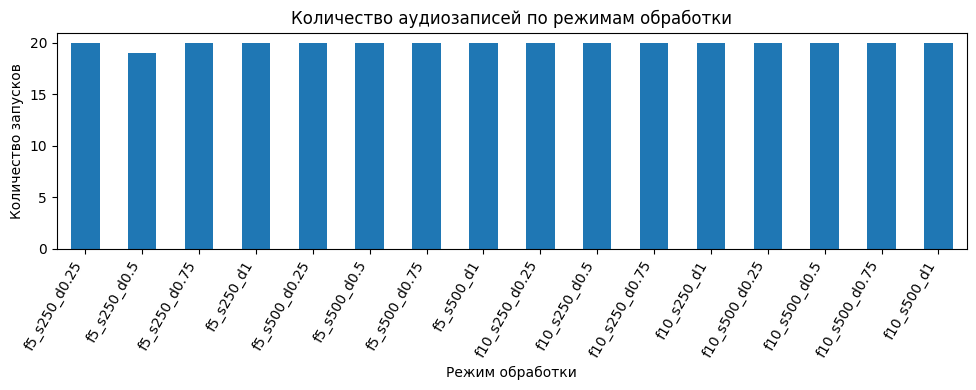

In [6]:
plt.figure(figsize=(10, 4))
condition_summary.plot(
    x="condition_id",
    y="runs_count",
    kind="bar",
    legend=False,
    ax=plt.gca(),
)
plt.title("Количество аудиозаписей по режимам обработки")
plt.xlabel("Режим обработки")
plt.ylabel("Количество запусков")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "runs_per_condition.png", dpi=150)
plt.show()

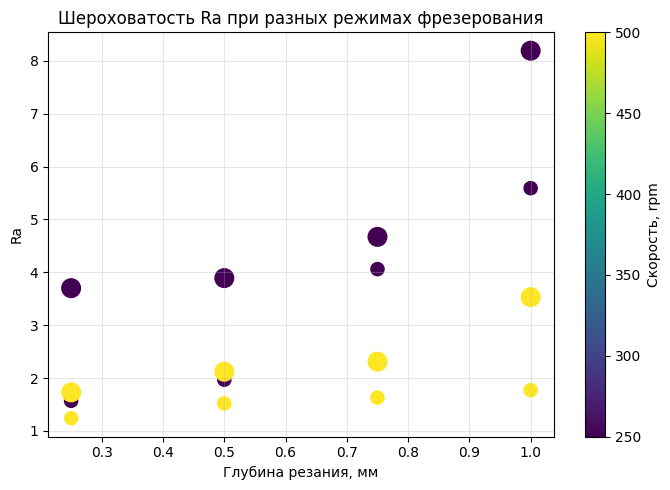

In [7]:
plt.figure(figsize=(7, 5))
scatter = plt.scatter(
    roughness["depth_mm"],
    roughness["roughness_ra"],
    c=roughness["speed_rpm"],
    s=roughness["feed_mm"] * 18,
    cmap="viridis",
)
plt.title("Шероховатость Ra при разных режимах фрезерования")
plt.xlabel("Глубина резания, мм")
plt.ylabel("Ra")
plt.colorbar(scatter, label="Скорость, rpm")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "roughness_by_mode.png", dpi=150)
plt.show()

## 5. Результат этапа

Первый этап завершен: таблицы для дальнейшего анализа сохранены в `data/processed`. Следующий этап - извлечение признаков из аудиосигналов и обучение моделей регрессии для предсказания `roughness_ra`.
